Görüntü Boyutu: (128, 128)
Piksel Değer Aralığı: 0 - 157
Ortalama Piksel Değeri: 47.25
Standart Sapma: 54.07


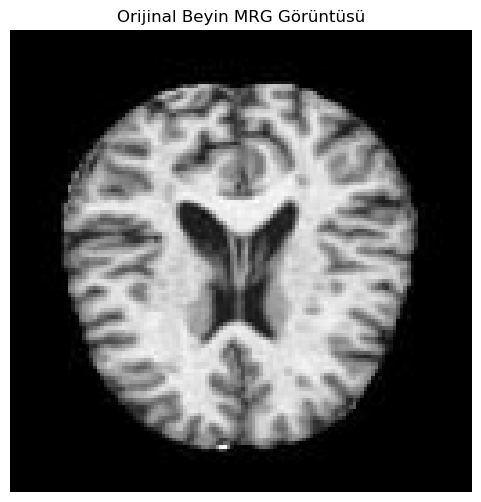

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Beyin MRG görüntüsünü gri tonlamalı olarak yükle:
img = cv2.imread('mri.jpg', cv2.IMREAD_GRAYSCALE)
# Görüntü bilgilerini yazdır
print(f"Görüntü Boyutu: {img.shape}")
print(f"Piksel Değer Aralığı: {img.min()} - {img.max()}")
print(f"Ortalama Piksel Değeri: {img.mean():.2f}")
print(f"Standart Sapma: {img.std():.2f}")

# Orijinal görüntüyü göster
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.title('Orijinal Beyin MRG Görüntüsü')
plt.axis('off')
plt.show()

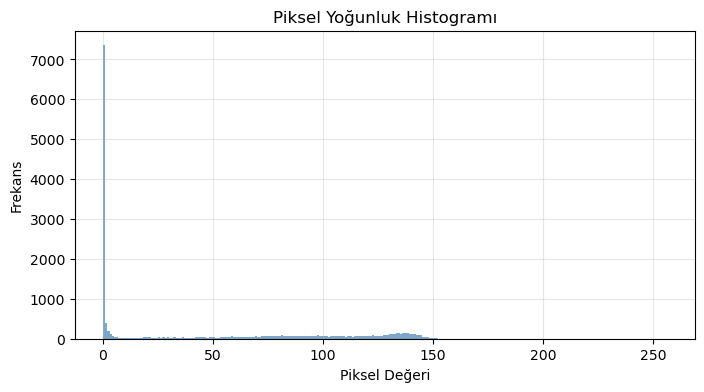

In [22]:
plt.figure(figsize=(8, 4))
plt.hist(img.ravel(), bins=256, range=[0, 256], color='steelblue', alpha=0.7)
plt.title('Piksel Yoğunluk Histogramı')
plt.xlabel('Piksel Değeri')
plt.ylabel('Frekans')
plt.grid(True, alpha=0.3)
plt.show()

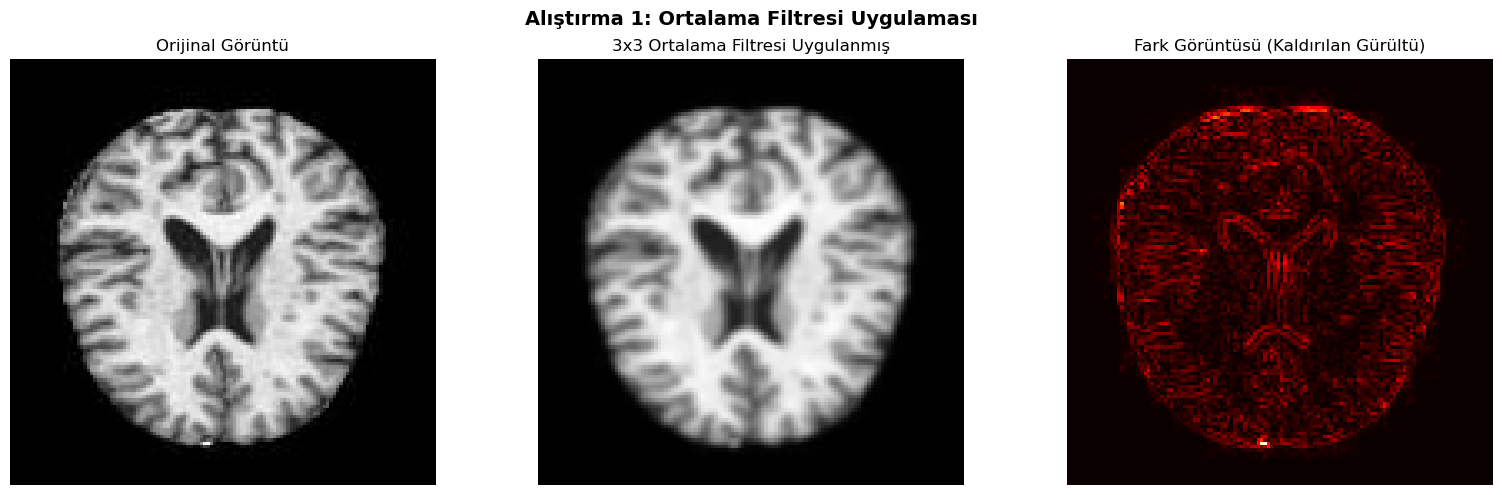

Ortalama Filtresi Sonuçları:
  Orijinal  - Ortalama: 47.25, Std: 54.07
  Filtrelenmiş - Ortalama: 47.25, Std: 52.86


In [23]:
# 3x3 boyutunda ortalama filtresi çekirdeği tanımla
kernel_3x3 = np.ones((3, 3), np.float32) / 9

# cv2.filter2D fonksiyonunu kullanarak filtreyi uygula
img_mean_filtered = cv2.filter2D(img, -1, kernel_3x3)

# Orijinal ve filtrelenmiş görüntüleri yan yana göster
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Orijinal Görüntü')
axes[0].axis('off')

axes[1].imshow(img_mean_filtered, cmap='gray')
axes[1].set_title('3x3 Ortalama Filtresi Uygulanmış')
axes[1].axis('off')

# Fark görüntüsü - filtrelemenin etkisini gösterir
diff_mean = cv2.absdiff(img, img_mean_filtered)
axes[2].imshow(diff_mean, cmap='hot')
axes[2].set_title('Fark Görüntüsü (Kaldırılan Gürültü)')
axes[2].axis('off')

plt.suptitle('Alıştırma 1: Ortalama Filtresi Uygulaması', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Ortalama Filtresi Sonuçları:")
print(f"  Orijinal  - Ortalama: {img.mean():.2f}, Std: {img.std():.2f}")
print(f"  Filtrelenmiş - Ortalama: {img_mean_filtered.mean():.2f}, Std: {img_mean_filtered.std():.2f}")

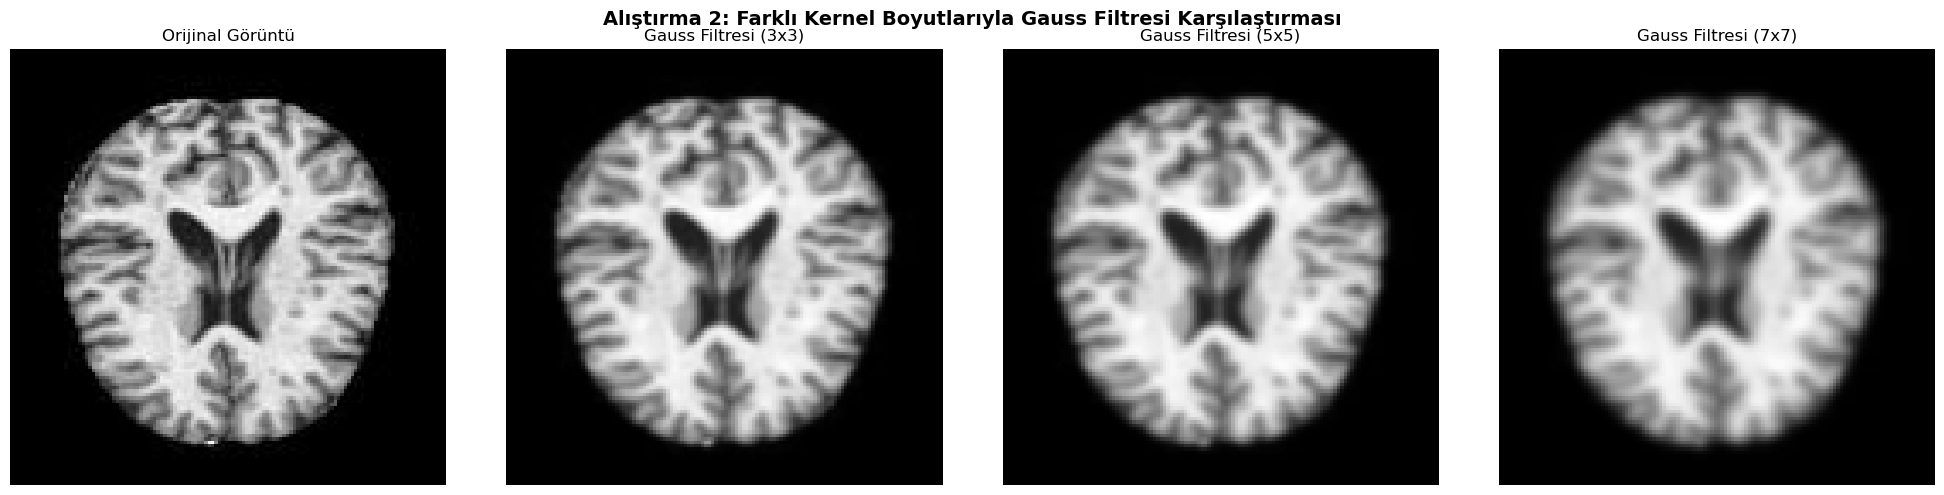

In [24]:
# Farklı kernel boyutlarıyla Gauss filtresi uygula
img_gauss_3x3 = cv2.GaussianBlur(img, (3, 3), 0)
img_gauss_5x5 = cv2.GaussianBlur(img, (5, 5), 0)
img_gauss_7x7 = cv2.GaussianBlur(img, (7, 7), 0)

# Sonuçları karşılaştır
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Orijinal Görüntü')
axes[0].axis('off')

axes[1].imshow(img_gauss_3x3, cmap='gray')
axes[1].set_title('Gauss Filtresi (3x3)')
axes[1].axis('off')

axes[2].imshow(img_gauss_5x5, cmap='gray')
axes[2].set_title('Gauss Filtresi (5x5)')
axes[2].axis('off')

axes[3].imshow(img_gauss_7x7, cmap='gray')
axes[3].set_title('Gauss Filtresi (7x7)')
axes[3].axis('off')

plt.suptitle('Alıştırma 2: Farklı Kernel Boyutlarıyla Gauss Filtresi Karşılaştırması',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

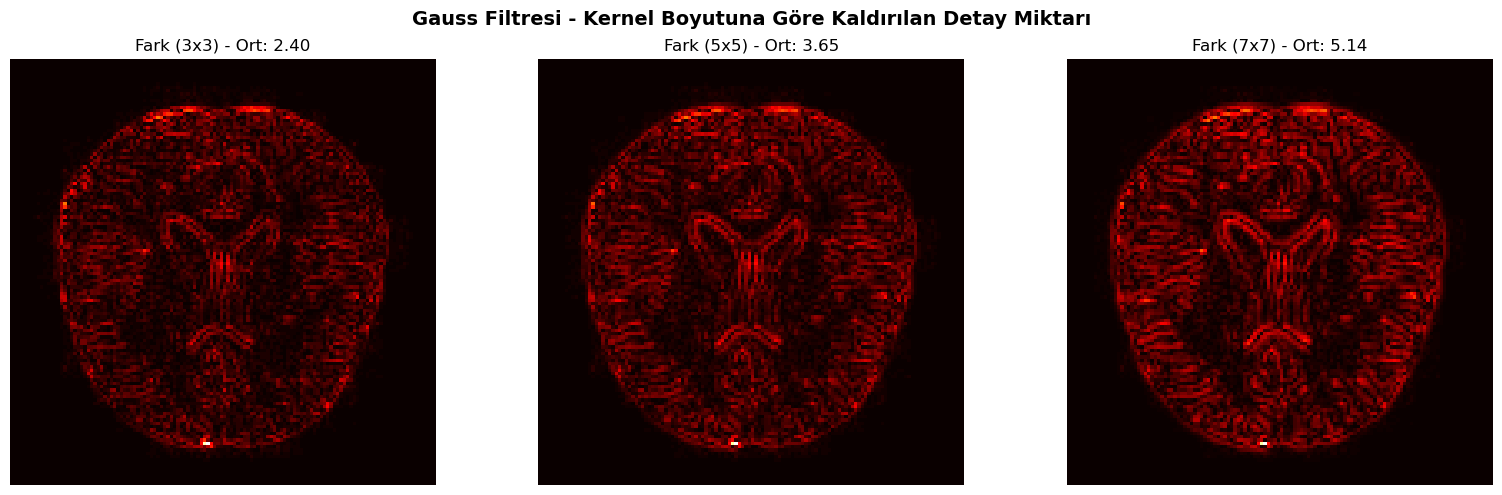

Gauss Filtresi Karşılaştırma Sonuçları:
  3x3 - Std: 53.11, Fark Ort: 2.40
  5x5 - Std: 52.51, Fark Ort: 3.65
  7x7 - Std: 51.78, Fark Ort: 5.14


In [25]:
# Fark görüntüleri ile yumuşatma etkisini göster
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

diff_3 = cv2.absdiff(img, img_gauss_3x3)
diff_5 = cv2.absdiff(img, img_gauss_5x5)
diff_7 = cv2.absdiff(img, img_gauss_7x7)

axes[0].imshow(diff_3, cmap='hot')
axes[0].set_title(f'Fark (3x3) - Ort: {diff_3.mean():.2f}')
axes[0].axis('off')

axes[1].imshow(diff_5, cmap='hot')
axes[1].set_title(f'Fark (5x5) - Ort: {diff_5.mean():.2f}')
axes[1].axis('off')

axes[2].imshow(diff_7, cmap='hot')
axes[2].set_title(f'Fark (7x7) - Ort: {diff_7.mean():.2f}')
axes[2].axis('off')

plt.suptitle('Gauss Filtresi - Kernel Boyutuna Göre Kaldırılan Detay Miktarı',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Gauss Filtresi Karşılaştırma Sonuçları:")
print(f"  3x3 - Std: {img_gauss_3x3.std():.2f}, Fark Ort: {diff_3.mean():.2f}")
print(f"  5x5 - Std: {img_gauss_5x5.std():.2f}, Fark Ort: {diff_5.mean():.2f}")
print(f"  7x7 - Std: {img_gauss_7x7.std():.2f}, Fark Ort: {diff_7.mean():.2f}")

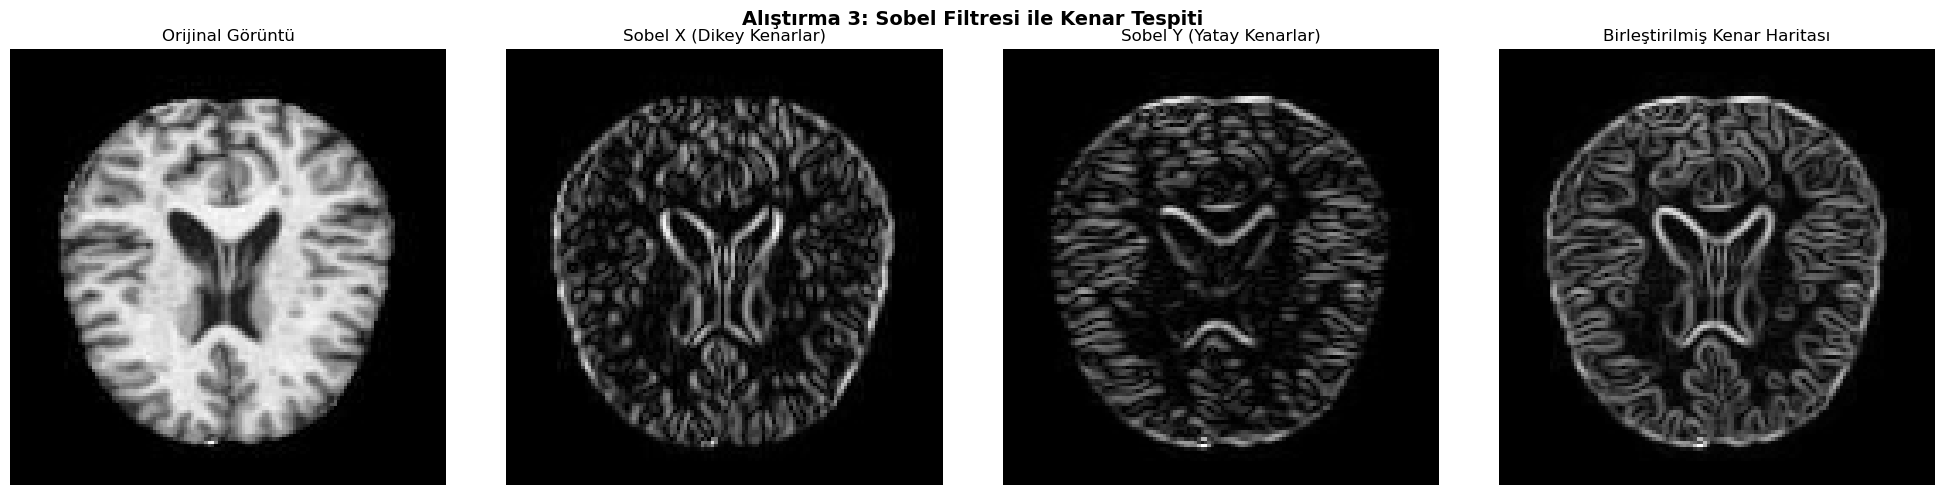

In [26]:
# Sobel filtresinin yatay ve dikey bileşenlerini hesapla
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)  # Dikey kenarlar
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)  # Yatay kenarlar

# Kenar büyüklüğünü hesapla (yatay ve dikey birleşimi)
sobel_combined = cv2.magnitude(sobel_x, sobel_y)

# Görselleştirme
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Orijinal Görüntü')
axes[0].axis('off')

axes[1].imshow(np.abs(sobel_x), cmap='gray')
axes[1].set_title('Sobel X (Dikey Kenarlar)')
axes[1].axis('off')

axes[2].imshow(np.abs(sobel_y), cmap='gray')
axes[2].set_title('Sobel Y (Yatay Kenarlar)')
axes[2].axis('off')

axes[3].imshow(sobel_combined, cmap='gray')
axes[3].set_title('Birleştirilmiş Kenar Haritası')
axes[3].axis('off')

plt.suptitle('Alıştırma 3: Sobel Filtresi ile Kenar Tespiti', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

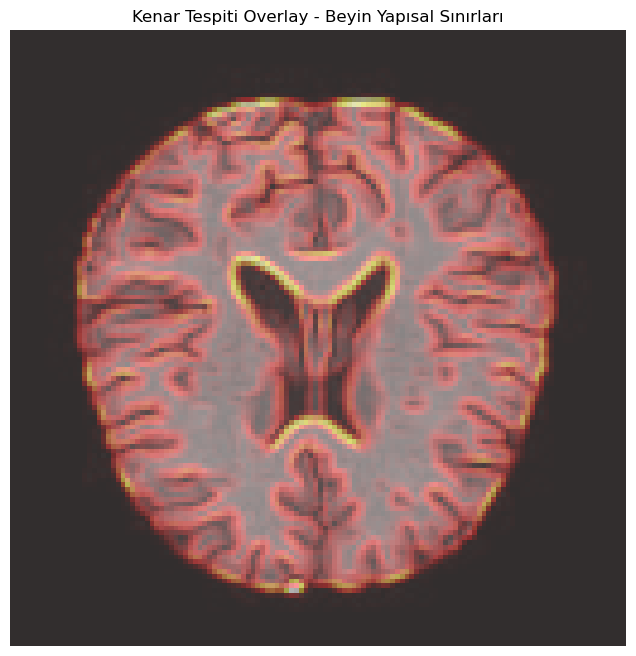

In [27]:
# Kenar haritasının orijinal görüntü üzerine bindirilmesi (overlay)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(img, cmap='gray', alpha=0.7)
sobel_norm = sobel_combined / sobel_combined.max()
ax.imshow(sobel_norm, cmap='hot', alpha=0.4)
ax.set_title('Kenar Tespiti Overlay - Beyin Yapısal Sınırları')
ax.axis('off')
plt.show()

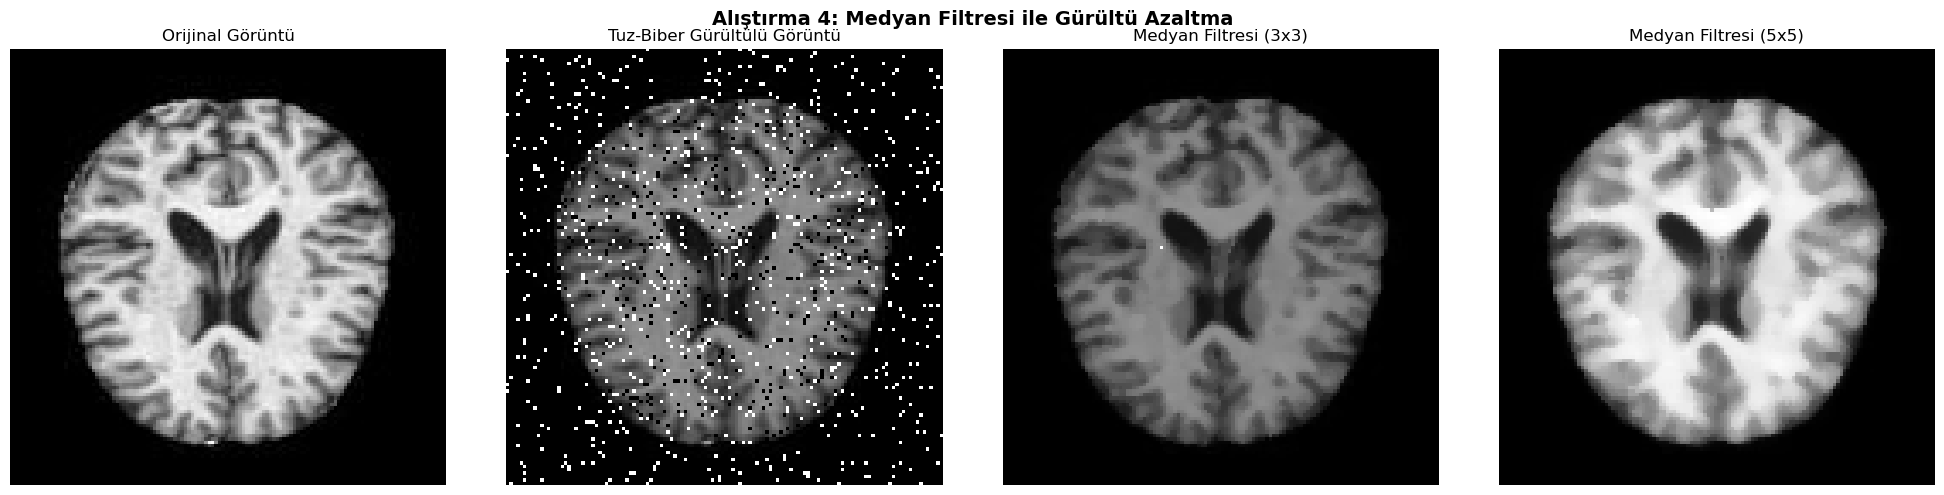

In [28]:
def add_salt_pepper_noise(image, amount=0.05):
    """Görüntüye tuz-biber gürültüsü ekler."""
    noisy = image.copy()
    # Tuz (beyaz) gürültüsü
    num_salt = int(amount * image.size)
    coords_salt = [np.random.randint(0, i, num_salt) for i in image.shape]
    noisy[coords_salt[0], coords_salt[1]] = 255
    # Biber (siyah) gürültüsü
    num_pepper = int(amount * image.size)
    coords_pepper = [np.random.randint(0, i, num_pepper) for i in image.shape]
    noisy[coords_pepper[0], coords_pepper[1]] = 0
    return noisy

# Görüntüye tuz-biber gürültüsü ekle
img_noisy = add_salt_pepper_noise(img, amount=0.05)

# Farklı kernel boyutlarıyla medyan filtresi uygula
img_median_3 = cv2.medianBlur(img_noisy, 3)
img_median_5 = cv2.medianBlur(img_noisy, 5)

# Sonuçları karşılaştır
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Orijinal Görüntü')
axes[0].axis('off')

axes[1].imshow(img_noisy, cmap='gray')
axes[1].set_title('Tuz-Biber Gürültülü Görüntü')
axes[1].axis('off')

axes[2].imshow(img_median_3, cmap='gray')
axes[2].set_title('Medyan Filtresi (3x3)')
axes[2].axis('off')

axes[3].imshow(img_median_5, cmap='gray')
axes[3].set_title('Medyan Filtresi (5x5)')
axes[3].axis('off')

plt.suptitle('Alıştırma 4: Medyan Filtresi ile Gürültü Azaltma', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

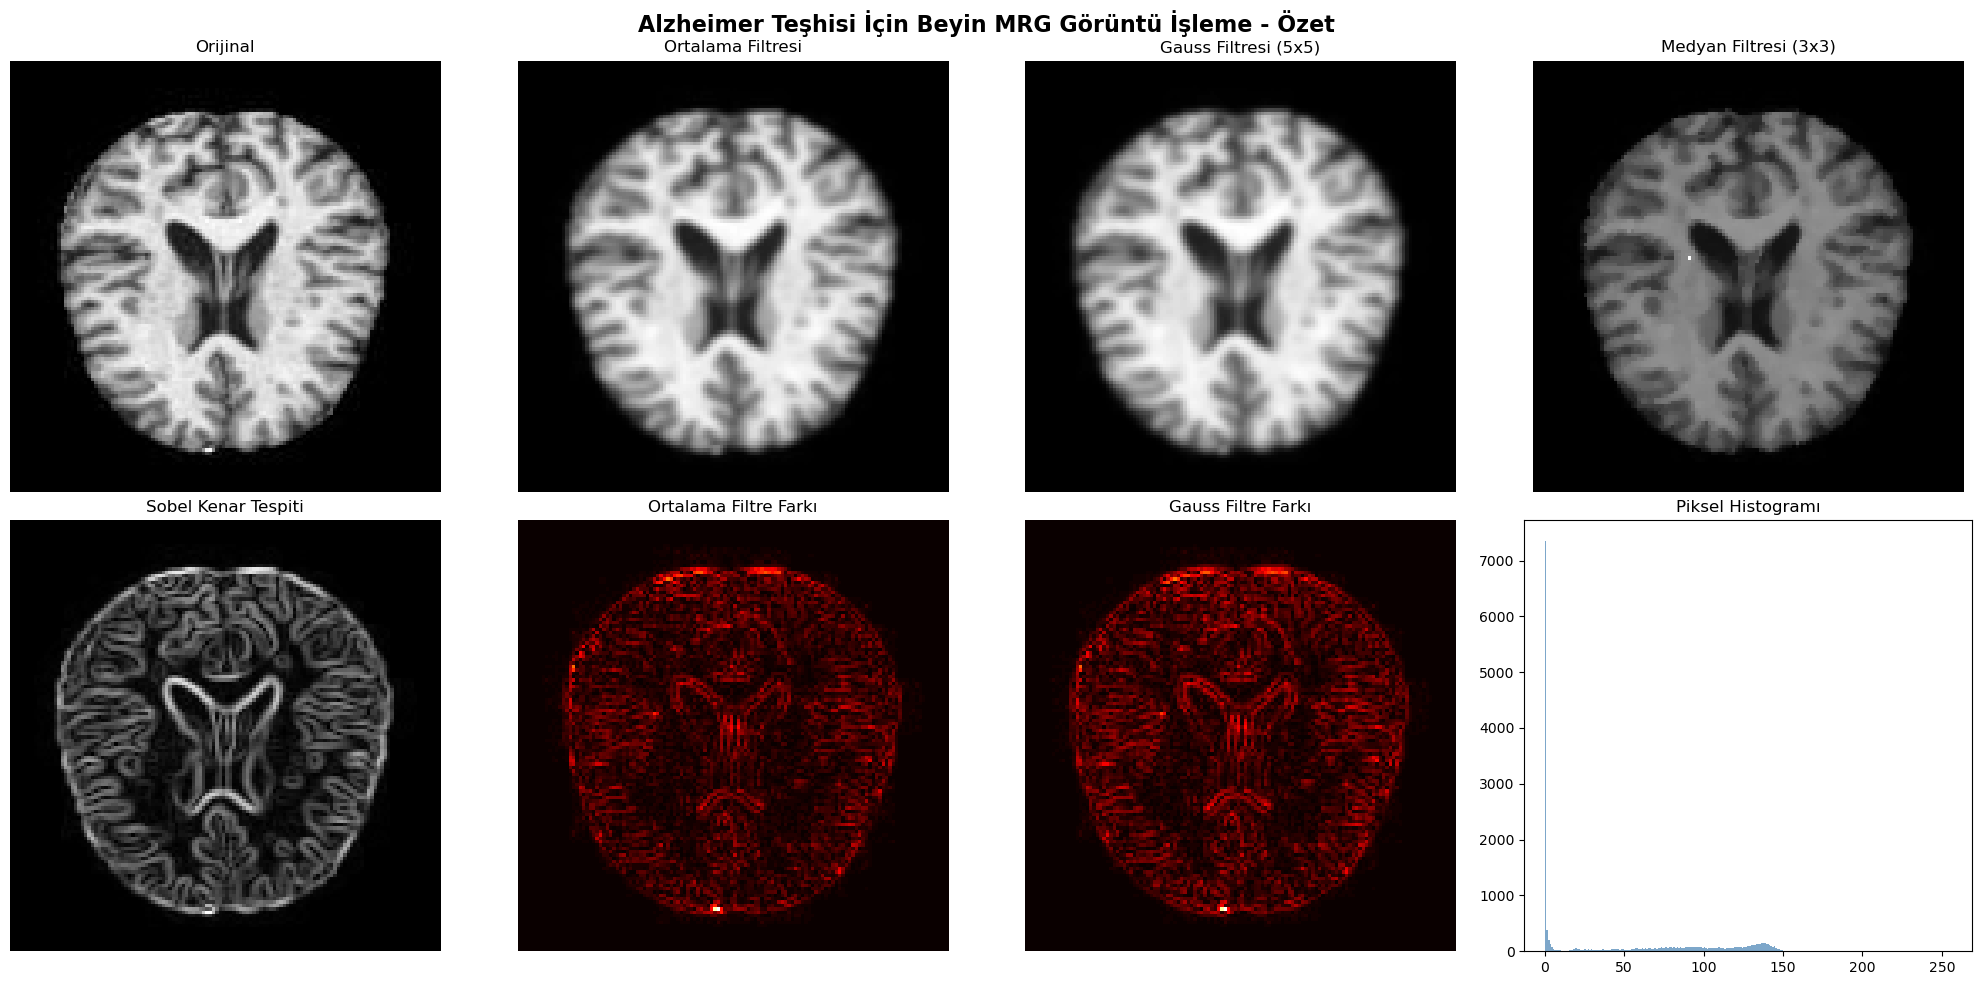

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Üst satır: Filtrelenmiş görüntüler
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Orijinal')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_mean_filtered, cmap='gray')
axes[0, 1].set_title('Ortalama Filtresi')
axes[0, 1].axis('off')

axes[0, 2].imshow(img_gauss_5x5, cmap='gray')
axes[0, 2].set_title('Gauss Filtresi (5x5)')
axes[0, 2].axis('off')

axes[0, 3].imshow(img_median_3, cmap='gray')
axes[0, 3].set_title('Medyan Filtresi (3x3)')
axes[0, 3].axis('off')

# Alt satır: Kenar tespiti ve analizler
axes[1, 0].imshow(sobel_combined, cmap='gray')
axes[1, 0].set_title('Sobel Kenar Tespiti')
axes[1, 0].axis('off')

axes[1, 1].imshow(diff_mean, cmap='hot')
axes[1, 1].set_title('Ortalama Filtre Farkı')
axes[1, 1].axis('off')

axes[1, 2].imshow(diff_5, cmap='hot')
axes[1, 2].set_title('Gauss Filtre Farkı')
axes[1, 2].axis('off')

axes[1, 3].hist(img.ravel(), bins=256, range=[0, 256], color='steelblue', alpha=0.7)
axes[1, 3].set_title('Piksel Histogramı')

plt.suptitle('Alzheimer Teşhisi İçin Beyin MRG Görüntü İşleme - Özet',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()